<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_6_ResNet_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 6 — Классификация кадров через ResNet

Прогоняем кадры через предобученный ResNet50 (ImageNet), получаем топ-5 классов для каждого кадра.

In [ ]:
!pip install torch torchvision Pillow tqdm -q

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

BASE_DRIVE  = '/content/drive/MyDrive/cv-frames'
VIDEO_DIR   = f'{BASE_DRIVE}/видио'
FRAMES_DIR  = f'{BASE_DRIVE}/кадры'
RESULTS_DIR = f'{BASE_DRIVE}/результаты'

for d in [VIDEO_DIR, FRAMES_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
frames = sorted(f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg'))
print(f'кадров: {len(frames)}')

In [ ]:
import json
import torch
import urllib.request
from torchvision import models, transforms

urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json',
    '/content/imagenet_labels.json'
)
with open('/content/imagenet_labels.json') as f:
    LABELS = json.load(f)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
print(f'resnet50 готов, устройство: {device}')

In [ ]:
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

rows = []

with torch.no_grad():
    for fname in tqdm(frames, desc='resnet'):
        img = Image.open(f'{FRAMES_DIR}/{fname}').convert('RGB')
        inp = transform(img).unsqueeze(0).to(device)
        probs = torch.softmax(model(inp), dim=1)[0]
        top5 = torch.topk(probs, 5)
        for rank, (idx, prob) in enumerate(zip(top5.indices.tolist(), top5.values.tolist()), 1):
            rows.append({'frame': fname, 'rank': rank, 'class': LABELS[idx], 'prob': round(prob, 4)})

df = pd.DataFrame(rows)
df.to_csv(f'{RESULTS_DIR}/resnet_classifications.csv', index=False)
print(f'обработано кадров: {len(frames)}')
df[df['rank'] == 1].head(10)


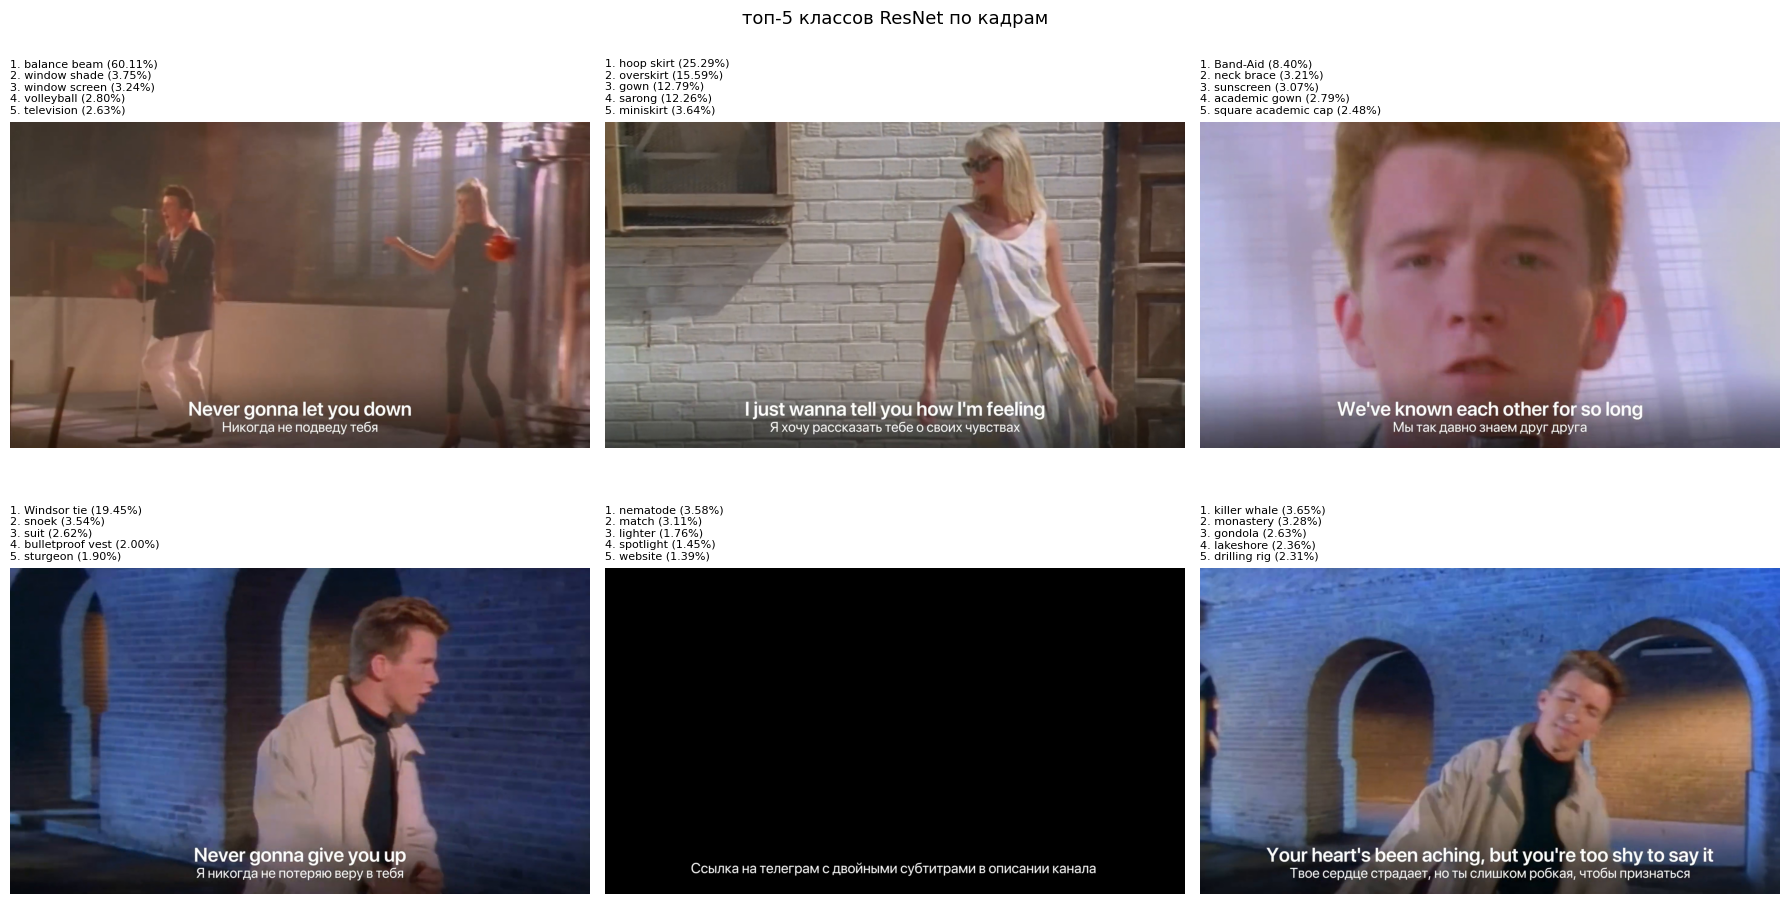

In [11]:
import cv2
import matplotlib.pyplot as plt

# показать 6 случайных кадров с топ-5 классами
sample_frames = df[df['rank'] == 1].sample(min(6, len(frames)), random_state=42)['frame'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, fname in zip(axes, sample_frames):
    img = cv2.imread(f'{FRAMES_DIR}/{fname}')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.axis('off')

    top5 = df[df['frame'] == fname].sort_values('rank')
    label = '\n'.join(
        f"{row['rank']}. {row['class']} ({row['prob']:.2%})"
        for _, row in top5.iterrows()
    )
    ax.set_title(label, fontsize=8, loc='left')

plt.suptitle('топ-5 классов ResNet по кадрам', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/resnet_summary.png', dpi=100, bbox_inches='tight')
plt.show()
